# Chapter 19. Quantum Transfer Learning

**Quantum AI: 핸즈온 양자머신러닝 with PennyLane — Part 3**

## 학습 목표
- 작은 사전훈련 CNN을 직접 만들고 freeze
- 양자 헤드를 붙여 새로운 분류 작업 학습
- Frozen 백본 + 학습 가능한 양자 head 패턴 체험

In [15]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0)

## 19.1 사전훈련 백본 만들기
torchvision이 없으므로, 작은 CNN을 직접 학습해 "사전훈련 모델"을 만든다.
Source 작업: 숫자 0 vs 1 분류

In [16]:
data = load_digits()
images = data.images / 16.0
labels = data.target

# Source 데이터: 0과 1
mask_src = labels < 2
X_src = images[mask_src][:, None, :, :]  # add channel dim
y_src = labels[mask_src]
X_src = torch.tensor(X_src, dtype=torch.float32)
y_src = torch.tensor(y_src, dtype=torch.long)
print(f'Source 데이터: {X_src.shape}, 클래스: {np.bincount(y_src)}')

Source 데이터: torch.Size([360, 1, 8, 8]), 클래스: [178 182]


In [17]:
# 작은 CNN 정의
class SmallCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8 → 4x4
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # → 1x1
            nn.Flatten(),  # → 16
        )
        self.head = nn.Linear(16, n_classes)

    def forward(self, x):
        return self.head(self.backbone(x))

src_model = SmallCNN(n_classes=2)
print(src_model)

SmallCNN(
  (backbone): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AdaptiveAvgPool2d(output_size=1)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (head): Linear(in_features=16, out_features=2, bias=True)
)


In [18]:
# Source 작업 학습 (사전훈련)
opt = torch.optim.Adam(src_model.parameters(), lr=0.01)
crit = nn.CrossEntropyLoss()
for ep in range(20):
    opt.zero_grad()
    loss = crit(src_model(X_src), y_src)
    loss.backward()
    opt.step()

with torch.no_grad():
    acc = (src_model(X_src).argmax(1) == y_src).float().mean().item()
print(f'사전훈련 완료 (source 정확도: {acc:.3f})')

사전훈련 완료 (source 정확도: 0.986)


## 19.2 Target 작업: 0/1/2 3-클래스
Source에서 학습한 백본을 가져와 새로운 분류 작업을 양자 헤드로 학습한다.

In [19]:
# Target 데이터: 0, 1, 2 (3-class)
mask_tgt = labels < 3
X_tgt = images[mask_tgt][:, None, :, :]
y_tgt = labels[mask_tgt]
X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
    X_tgt, y_tgt, test_size=0.3, random_state=0, stratify=y_tgt
)
X_tr_t = torch.tensor(X_tr_t, dtype=torch.float32)
X_te_t = torch.tensor(X_te_t, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_t, dtype=torch.long)
y_te_t = torch.tensor(y_te_t, dtype=torch.long)
print(f'Target 학습: {X_tr_t.shape}, 테스트: {X_te_t.shape}')

Target 학습: torch.Size([375, 1, 8, 8]), 테스트: torch.Size([162, 1, 8, 8])


## 19.3 Frozen backbone + Quantum head
백본의 파라미터를 freeze하고 새 양자 헤드만 학습한다.

In [20]:
# 백본 freeze
for p in src_model.backbone.parameters():
    p.requires_grad = False

# 양자 헤드 정의
n_q = 4
dev = qml.device('default.qubit', wires=n_q)

@qml.qnode(dev, interface='torch')
def head_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_q), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_q))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_q)]

ws = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=n_q)
qhead = qml.qnn.TorchLayer(head_circuit, {'weights': ws})

class TransferModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = src_model.backbone  # frozen
        # 16-dim 백본 출력 → 4-dim → 양자 → 3-class
        self.bridge = nn.Sequential(nn.Linear(16, n_q), nn.Tanh())
        self.qhead = qhead
        self.classifier = nn.Linear(n_q, 3)

    def forward(self, x):
        features = self.backbone(x)
        x = self.bridge(features)
        x = self.qhead(x)
        return self.classifier(x)

transfer = TransferModel()

# 학습 가능한 파라미터만 출력
trainable = [p for p in transfer.parameters() if p.requires_grad]
print(f'학습 가능 파라미터 수: {sum(p.numel() for p in trainable)}')

학습 가능 파라미터 수: 107


## 19.4 Transfer learning 학습

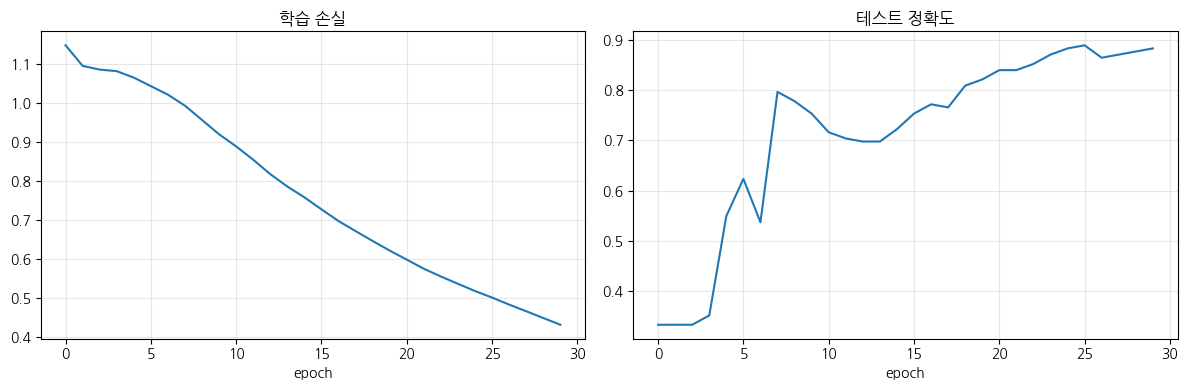

최종 테스트 정확도: 0.883


In [21]:
opt = torch.optim.Adam(trainable, lr=0.05)
crit = nn.CrossEntropyLoss()

history = []
for ep in range(30):
    opt.zero_grad()
    loss = crit(transfer(X_tr_t), y_tr_t)
    loss.backward()
    opt.step()
    with torch.no_grad():
        acc = (transfer(X_te_t).argmax(1) == y_te_t).float().mean().item()
    history.append((loss.item(), acc))

losses, accs = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses); axes[0].set_title('학습 손실')
axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(accs); axes[1].set_title('테스트 정확도')
axes[1].set_xlabel('epoch'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'최종 테스트 정확도: {accs[-1]:.3f}')

## 19.5 정리
- 사전훈련 백본을 freeze하면 학습 파라미터가 크게 줄어든다.
- 작은 양자 헤드만 학습해도 강력한 특징을 활용해 빠르게 수렴한다.
- 이 패턴이 NISQ 환경에서 매우 실용적이다.